Test train split
- Similar ratios for Female with

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [27]:

df_baseline = pd.read_csv("../data/processed/cardio_baseline_clean.csv")
df_feature_1 = pd.read_csv("../data/processed/cardio_bsa_pp.csv")

# Create a new column for stratification by combining 'cardio' and 'gender' columns
df_baseline["stratify"] = df_baseline["cardio"].astype(str) + "_" + df_baseline["gender"].astype(str)
df_feature_1["stratify"] = df_feature_1["cardio"].astype(str) + "_" + df_feature_1["gender"].astype(str)


# Split the data into training and testing sets with stratification
train_df, test_df = train_test_split(
    df_baseline,
    test_size=0.2,
    stratify=df_baseline["stratify"],
    random_state=42,
)

# Split feature engineered dataset
train_df_feat_1, test_df_feat_1 = train_test_split(
    df_feature_1,
    test_size=0.2,
    stratify=df_feature_1["stratify"],
    random_state=42,
)

# Save dataframes to CSV files
train_df.to_csv("../data/test_train_val_sets/cardio_baseline_train.csv", index=False)
test_df.to_csv("../data/test_train_val_sets/cardio_baseline_test.csv", index=False)

train_df_feat_1.to_csv("../data/test_train_val_sets/cardio_bsa_pp_train.csv", index=False)
test_df_feat_1.to_csv("../data/test_train_val_sets/cardio_bsa_pp_test.csv", index=False)


# print(test_df.columns)
# Compare Proportions of 'stratify' in the full dataset, training set, and testing set
# full_prop  = df_baseline["stratify"].value_counts(normalize=True).sort_index()
# train_prop = train_df["stratify"].value_counts(normalize=True).sort_index()
# test_prop  = test_df["stratify"].value_counts(normalize=True).sort_index()


# comparison_table = pd.concat([full_prop, train_prop, test_prop], axis=1)
# comparison_table.columns = ["Full Dataset", "Train Set", "Test Set"]
# # print(comparison_table)


# # Calculate the counts of each stratification group in the full dataset : For reference
# female_neg = df_baseline[df_baseline["stratify"] == "0_0"].shape[0]
# female_pos = df_baseline[df_baseline["stratify"] == "1_0"].shape[0]
# male_neg   = df_baseline[df_baseline["stratify"] == "0_1"].shape[0]
# male_pos   = df_baseline[df_baseline["stratify"] == "1_1"].shape[0]


# print(f"Females cardio=0: {female_neg}")
# print(f"Females cardio=1: {female_pos}")
# print(f"Female neg/pos ratio: {female_neg/female_pos if female_pos else 'inf'}")

# print(f"Males cardio=0: {male_neg}")
# print(f"Males cardio=1: {male_pos}")
# print(f"Male neg/pos ratio: {male_neg/male_pos if male_pos else 'inf'}")

# print(df_baseline["stratify"].value_counts())
# print(df_baseline["stratify"].value_counts(normalize=True))

In [ ]:
# pretty_table = comparison_table.copy()

# # Rename rows to be readable
# label_map = {
#     "0_0": "Female – No CVD",
#     "1_0": "Female – CVD",
#     "0_1": "Male – No CVD",
#     "1_1": "Male – CVD",
# }

# pretty_table.index = pretty_table.index.map(label_map)

# # Convert to percentages
# pretty_table = (pretty_table * 100).round(2)

# print("\nStratified Proportions (%)")
# print(pretty_table)
# balance_table = pd.DataFrame({
#     "Cardio = 0": [female_neg, male_neg],
#     "Cardio = 1": [female_pos, male_pos],
#     "Neg/Pos Ratio": [
#         round(female_neg / female_pos, 3),
#         round(male_neg / male_pos, 3)
#     ]
# }, index=["Female", "Male"])

# print("\nClass Balance by Sex")
# print(balance_table)


Stratified Proportions (%)
                 Full Dataset  Train Set  Test Set
stratify                                          
Female – No CVD         32.95      32.95     32.94
Male – No CVD           17.51      17.51     17.51
Female – CVD            32.08      32.08     32.08
Male – CVD              17.47      17.47     17.47

Class Balance by Sex
        Cardio = 0  Cardio = 1  Neg/Pos Ratio
Female       22492       21901          1.027
Male         11953       11924          1.002


VERY Balanced!!

# Dataset Split Overview

The dataset was stratified by **cardiovascular outcome (`cardio`) and sex (`gender`)** to preserve the joint distribution across training and test sets.

The stratification variable was defined as: stratfy = cardio+"_"+gender

Where:

- `0_0` → Female, No CVD  
- `1_0` → Female, CVD  
- `0_1` → Male, No CVD  
- `1_1` → Male, CVD  


**Note:** - The proportions in the train and test sets closely match those of the full dataset, confirming successful stratified sampling.

---

#### Class Balance by Sex
More female than male but imbalance is very less

### Summary

- The dataset is approximately balanced overall.
- Within each sex, the cardiovascular outcome distribution is balanced.
- Stratified splitting preserved both outcome and sex proportions across training and testing sets.


# Train models
- Rn only XGBoost with baseline
- Adding simple feature engineered model - BSA and Pulse pressure introduced - dependendent features NOT removed (ap_hi, ap_lo, weight, height)

In [28]:
# XGBoost trained on baseline dataset
X_train = train_df.drop(columns=["cardio", "stratify"])
y_train = train_df["cardio"]

X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]

X_train_feat_1 = train_df_feat_1.drop(columns=["cardio", "stratify"])
y_train_feat_1 = train_df_feat_1["cardio"]

X_test_feat_1 = test_df_feat_1.drop(columns=["cardio", "stratify"])
y_test_feat_1 = test_df_feat_1["cardio"]






In [13]:
from xgboost import XGBClassifier

In [9]:
#Baseline model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
)
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [29]:
model_feat_1 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
)

model_feat_1.fit(X_train_feat_1, y_train_feat_1)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [10]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(roc_auc_score(y_test, y_pred_proba))

import pickle

with open("baseline_models/cardio_xgb_baseline_model.pkl", "wb") as f:
    pickle.dump(model, f)
    

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6880
           1       0.76      0.68      0.72      6756

    accuracy                           0.74     13636
   macro avg       0.74      0.74      0.74     13636
weighted avg       0.74      0.74      0.74     13636

AUROC: 0.801
0.8005126149710162


In [37]:
from sklearn.model_selection import GridSearchCV

# Fine tuning parametere search
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="recall",   # or "roc_auc" / "f1"
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_feat_1, y_train_feat_1)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


KeyboardInterrupt: 

In [41]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,          # number of random combinations to try
    scoring="recall",   # or "f1" or "roc_auc"
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_feat_1, y_train_feat_1)

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best CV score: 0.7006041094975443


In [35]:
y_pred_feat_1 = model_feat_1.predict(X_test_feat_1)
y_pred_proba_feat_1 = model_feat_1.predict_proba(X_test_feat_1)[:, 1]

print(X_train_feat_1.columns)
from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_test_feat_1, y_pred_feat_1))
print(f"AUROC: {roc_auc_score(y_test_feat_1, y_pred_proba_feat_1):.3f}")
print(roc_auc_score(y_test_feat_1, y_pred_proba_feat_1))


import pickle

with open("baseline_models/cardio_xgb_bsa_pp_model.pkl", "wb") as f:
    pickle.dump(model_feat_1, f)

Index(['id', 'age', 'gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'age_years', 'BMI', 'BSA',
       'Pulse pressure', 'chol_gluc_interaction'],
      dtype='str')
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      7004
           1       0.75      0.70      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000

AUROC: 0.802
0.8019293638953024


In [53]:
best_model = search.best_estimator_

y_pred_best = best_model.predict(X_test_feat_1)
y_proba_best = best_model.predict_proba(X_test_feat_1)[:, 1]

threshold = 0.4   # try 0.3–0.5
y_pred_best = (y_proba_best >= threshold).astype(int)

print(classification_report(y_test_feat_1, y_pred_best))
print("AUROC:", roc_auc_score(y_test_feat_1, y_proba_best))

              precision    recall  f1-score   support

           0       0.76      0.66      0.70      7004
           1       0.70      0.79      0.74      6996

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000

AUROC: 0.8011922514097147


Gender-specific metrics
- Does recall drop for women?

In [7]:
test_female = test_df[test_df["gender"] == 0]
test_male = test_df[test_df["gender"] == 1]

X_test_female = test_female.drop(columns=["cardio", "stratify"])
X_test_male = test_male.drop(columns=["cardio", "stratify"])

y_test_female = y_test[test_df["gender"] == 0]
y_test_male = y_test[test_df["gender"] == 1]

In [8]:
# Female specific evaluation

y_pred_female = model.predict(X_test_female)
y_pred_proba_female = model.predict_proba(X_test_female)[:, 1]

y_pred_male = model.predict(X_test_male)
y_pred_proba_male = model.predict_proba(X_test_male)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(roc_auc_score(y_test, y_pred_proba))

print("Female Specific Evaluation:")
print(classification_report(y_test_female, y_pred_female))
print(f"Female AUROC: {roc_auc_score(y_test_female, y_pred_proba_female):.3f}")
print(roc_auc_score(y_test_female, y_pred_proba_female))    


print("Male Specific Evaluation:")
print(classification_report(y_test_male, y_pred_male))
print(f"Male AUROC: {roc_auc_score(y_test_male, y_pred_proba_male):.3f}")
print(roc_auc_score(y_test_male, y_pred_proba_male))        

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6889
           1       0.76      0.69      0.72      6765

    accuracy                           0.74     13654
   macro avg       0.74      0.74      0.74     13654
weighted avg       0.74      0.74      0.74     13654

AUROC: 0.802
0.8019837853269729
Female Specific Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      4498
           1       0.75      0.69      0.72      4380

    accuracy                           0.74      8878
   macro avg       0.74      0.74      0.74      8878
weighted avg       0.74      0.74      0.74      8878

Female AUROC: 0.806
0.8058528549472013
Male Specific Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      2391
           1       0.76      0.69      0.72      2385

    accuracy                      

Metrics on the feature engineered model


In [51]:
# Split by gender (feature engineered dataset)

test_female_feat_1 = test_df_feat_1[test_df_feat_1["gender"] == 0]
test_male_feat_1 = test_df_feat_1[test_df_feat_1["gender"] == 1]

X_test_female_feat_1 = test_female_feat_1.drop(columns=["cardio", "stratify"])
X_test_male_feat_1 = test_male_feat_1.drop(columns=["cardio", "stratify"])

y_test_female_feat_1 = y_test_feat_1[test_df_feat_1["gender"] == 0]
y_test_male_feat_1 = y_test_feat_1[test_df_feat_1["gender"] == 1]

In [58]:
# Predictions (feature engineered model)

y_pred_female_feat_1 = model_feat_1.predict(X_test_female_feat_1)
y_pred_proba_female_feat_1 = model_feat_1.predict_proba(X_test_female_feat_1)[:, 1]

y_pred_male_feat_1 = model_feat_1.predict(X_test_male_feat_1)
y_pred_proba_male_feat_1 = model_feat_1.predict_proba(X_test_male_feat_1)[:, 1]

In [55]:
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report (Feature Engineered Model):")
print(classification_report(y_test_feat_1, y_pred_feat_1))
print(f"AUROC: {roc_auc_score(y_test_feat_1, y_pred_proba_feat_1):.3f}")
print(roc_auc_score(y_test_feat_1, y_pred_proba_feat_1))

Classification Report (Feature Engineered Model):
              precision    recall  f1-score   support

           0       0.76      0.66      0.70      7004
           1       0.70      0.79      0.74      6996

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000

AUROC: 0.802
0.8019293638953024


In [48]:
print("Female Specific Evaluation (Feature Engineered Model):")
print(classification_report(y_test_female_feat_1, y_pred_female_feat_1))
print(f"Female AUROC: {roc_auc_score(y_test_female_feat_1, y_pred_proba_female_feat_1):.3f}")
print(roc_auc_score(y_test_female_feat_1, y_pred_proba_female_feat_1))

Female Specific Evaluation (Feature Engineered Model):
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      4583
           1       0.75      0.70      0.72      4523

    accuracy                           0.73      9106
   macro avg       0.73      0.73      0.73      9106
weighted avg       0.73      0.73      0.73      9106

Female AUROC: 0.803
0.8027836149022604


In [49]:
print("Male Specific Evaluation (Feature Engineered Model):")
print(classification_report(y_test_male_feat_1, y_pred_male_feat_1))
print(f"Male AUROC: {roc_auc_score(y_test_male_feat_1, y_pred_proba_male_feat_1):.3f}")
print(roc_auc_score(y_test_male_feat_1, y_pred_proba_male_feat_1))

Male Specific Evaluation (Feature Engineered Model):
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      2421
           1       0.75      0.70      0.73      2473

    accuracy                           0.73      4894
   macro avg       0.73      0.73      0.73      4894
weighted avg       0.73      0.73      0.73      4894

Male AUROC: 0.800
0.8002904729191751


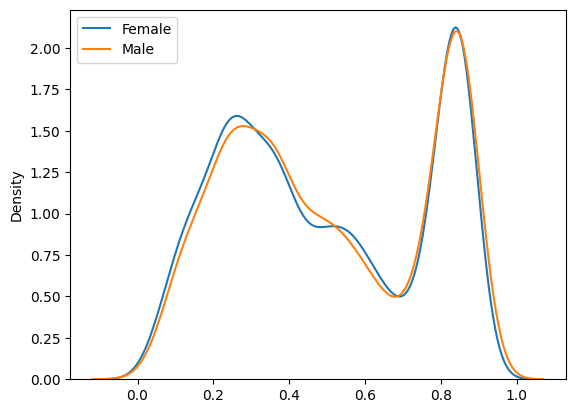

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(y_pred_proba_female_feat_1, label="Female")
sns.kdeplot(y_pred_proba_male_feat_1, label="Male")
plt.legend()

Looking at woman false negatives


In [9]:
# ── Additional code: SHAP False-Negative Analysis ────────────────────────────
# Paste this after your existing model evaluation code
# import shap

import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib as plt

MATCHING_FEATURES = ["age", "ap_hi", "cholesterol", "weight"]

# 1. Identify false-negative women (true=1, predicted=0, gender=0)
fn_mask    = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 0)
fn_women   = test_df[fn_mask].copy()
fn_women_X = X_test[fn_mask].copy()
print(f"False-negative women: {len(fn_women)}")

# 2. Pick most representative FN woman (closest to median profile)
fn_std     = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median  = fn_women[MATCHING_FEATURES].median()
distances  = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1
)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# 3. Find nearest male in test set (z-score normalised L2 distance)
males   = test_df[test_df["gender"] == 1].copy()
males_X = X_test[test_df["gender"].values == 1].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("\nFeature comparison (woman vs matched male):")
print(pd.DataFrame({
    "FN Woman":     rep_woman[MATCHING_FEATURES].values,
    "Matched Male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

# 4. SHAP explanations
explainer = shap.TreeExplainer(model)
woman_df  = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df   = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)
sv_woman  = explainer(woman_df)
sv_male   = explainer(male_df)

prob_woman = model.predict_proba(woman_df.values)[0, 1]
prob_male  = model.predict_proba(male_df.values)[0, 1]

# 5. Side-by-side waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="False-Negative Woman",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_male,  ax=axes[1], title="Matched Male",
         subtitle=f"Predicted: {'CVD' if model.predict(male_df.values)[0]==1 else 'No CVD'}  "
                  f"|  True: {'CVD' if rep_male['cardio']==1 else 'No CVD'}  (P={prob_male:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(p["title"], color=p["accent"], fontsize=15, fontweight="bold", pad=12)
    p["ax"].set_xlabel(p["subtitle"], color="#7a7d99", fontsize=9, labelpad=8)

fig.suptitle("SHAP Waterfall — False-Negative Woman vs Nearest Matched Male",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01,
         f"Matched on: age · SBP · cholesterol · weight  │  "
         f"Age W={int(rep_woman['age'])} / M={int(rep_male['age'])}  │  "
         f"SBP W={int(rep_woman['ap_hi'])} / M={int(rep_male['ap_hi'])}  │  "
         f"Chol W={int(rep_woman['cholesterol'])} / M={int(rep_male['cholesterol'])}  │  "
         f"Weight W={rep_woman['weight']:.1f} / M={rep_male['weight']:.1f} kg",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.savefig("shap_fn_woman_vs_matched_male.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# 6. Console SHAP driver summary
print("\nTop SHAP drivers (sorted by |woman SHAP|):")
print(pd.DataFrame({
    "feature":    X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(
    index=False, float_format="{:+.4f}".format))

False-negative women: 1337


KeyError: "['age'] not in index"